GOAL: test the equations coupling and the variable timestep.

L'équation de dissolution d'un mineral traceur et de l'évolution des concentrations s'écrit:

$$
  \forall n \in [0, N], \left\{
    \begin{array}{l}
      c_{i}^{n+1} = c_{i}^{n}(1 - D_{i}) - \overline{c}_{i}^{n+1} + \overline{c}_{i}^{n}
      \\
      \overline{c}_{i}^{n+1} = \overline{c}_{i}^{n} + \Delta t^{n} k_{v} A_{s} \overline{c}_{i}^{n} \left( 1 - \dfrac{c_{i}^{n+1}}{K_{s}}\right)
    \end{array}
  \right.
$$

And the fixed point iteration criteria, $ \text{max}_{i} \left\lVert 1 - \dfrac{\overline{c}^{k}}{\overline{c}^{k-1}} \right\rVert  < \epsilon $, with $\overline{c}^{k}$ and $\overline{c}^{k-1}$ the immobile concentrations at the last and before last fixed point iterations.


$$ \mathcal{L} = \dfrac{1}{2} \sum_{n=0}^{N} \sum_{i} \left( \dfrac{c_{i}^{n, \mathrm{obs}} - c_{i}^{n, \mathrm{calc}}}{\sigma_{c_{i}^{n, \mathrm{obs}}}}\right)^{2} - \langle \lambda_{c_{i}^{n+1}}, g_{c} \rangle - \langle \lambda_{\overline{c}_{i}^{n+1}}, g_{\overline{c}} \rangle $$

Explicitely it reads:

\begin{equation}
\begin{aligned}
\mathcal{L} = &\dfrac{1}{2} \sum_{n=0}^{N+1} \sum_{i} \left( \dfrac{c_{i}^{n, \mathrm{obs}} - c_{i}^{n, \mathrm{calc}}}{\sigma_{c_{i}}^{n, \mathrm{obs}}}\right)^{2} 
\\
&- \sum_{n=0}^{N} \lambda_{c_{i}}^{n+1}\Bigg[c_{i}^{n+1} - (1 - D_{i}) c_{i}^{n} + \overline{c}_{i}^{n+1} - \overline{c}_{i}^{n} \Bigg]
\\
&- \sum_{n=0}^{N} \lambda_{\overline{c}_{i}}^{n+1} \Bigg[\overline{c}_{i}^{n+1} - \overline{c}_{i}^{n} - \Delta t^{n} k_{v} A_{s} \overline{c}_{i}^{n} \left( 1 - \dfrac{c_{i}^{n+1}}{K_{s}}\right)
 \Bigg]  
\end{aligned}
\end{equation}

## 1) Derivation by $\overline{c}_{i}^{n}$:

$$
\dfrac{\partial \mathcal{L}}{\partial \overline{c}_{i}^{n}} =
\begin{cases}
    \lambda_{c_{i}}^{1} + \lambda_{\overline{c}_{i}}^{1} \left( 1 + \Delta t^{0} k_{v} A_{s} \left( 1 - \dfrac{c_{i}^{1}}{K_{s}}\right) \right) , & \text{if}\ n = 0 
    \\\\
    \lambda_{c_{i}}^{n+1} - \lambda_{c_{i}}^{n} + \lambda_{\overline{c}_{i}}^{n+1} - \lambda_{\overline{c}_{i}}^{n} + \lambda_{\overline{c}_{i}}^{n+1} \Delta t^{n} k_{v} A_{s} \left( 1 - \dfrac{c_{i}^{n+1}}{K_{s}}\right) , & \forall n \in [1, N] 
    \\\\
    - \lambda_{\overline{c}_{i}}^{N+1} - \lambda_{c_{i}}^{N+1}, & \text{if}\ n = N+1
\end{cases}
$$

Since we want to impose $\dfrac{\partial \mathcal{L}}{\partial \overline{c}_{i}^{n}} = 0$, it gives the initial condition for the adjoint state:

$$ \lambda_{\overline{c}_{i}}^{N+1} =  - \lambda_{c_{i}}^{N+1}$$

And the temporal evolution, $\left(\lambda_{c_{i}}^{n} - \lambda_{c_{i}}^{n+1}\right)$ being an "adjoint transport" error source term:

$$\lambda_{\overline{c}_{i}}^{n} = \lambda_{\overline{c}_{i}}^{n+1} \left(1 + \Delta t^{n} k_{v} A_{s} \left( 1 - \dfrac{c_{i}^{n+1}}{K_{s}}\right) \right) - \left(\lambda_{c_{i}}^{n} - \lambda_{c_{i}}^{n+1}\right), \forall n \in [1, N] $$


## 2) Derivation by $c_{i}^{n}$:

\begin{equation}
\begin{aligned}
\mathcal{L} = &\dfrac{1}{2} \sum_{n=0}^{N+1} \sum_{i} \left( \dfrac{c_{i}^{n, \mathrm{obs}} - c_{i}^{n, \mathrm{calc}}}{\sigma_{c_{i}}^{n, \mathrm{obs}}}\right)^{2} 
\\
&- \sum_{n=0}^{N} \lambda_{c_{i}}^{n+1}\Bigg[c_{i}^{n+1} - (1 - D_{i}) c_{i}^{n} + \overline{c}_{i}^{n+1} - \overline{c}_{i}^{n} \Bigg]
\\
&- \sum_{n=0}^{N} \lambda_{\overline{c}_{i}}^{n+1} \Bigg[\overline{c}_{i}^{n+1} - \overline{c}_{i}^{n} - \Delta t^{n} k_{v} A_{s} \overline{c}_{i}^{n} \left( 1 - \dfrac{c_{i}^{n+1}}{K_{s}}\right)
 \Bigg]  
\end{aligned}
\end{equation}

$$
\dfrac{\partial \mathcal{L}}{\partial c_{i}^{2n}} =
\begin{cases}
    - \dfrac{c_{i}^{0, \mathrm{obs}} - c_{i}^{0, \mathrm{calc}}}{\left(\sigma_{c_{i}}^{0, \mathrm{obs}}\right)^{2}} + \lambda_{c_{i}}^{1} (1 - D_{i}), & \text{if}\ n = 0 
    \\\\
    - \dfrac{c_{i}^{n, \mathrm{obs}} - c_{i}^{n, \mathrm{calc}}}{\left(\sigma_{c_{i}}^{n, \mathrm{obs}}\right)^{2}} + \lambda_{c_{i}}^{n+1} (1 - D_{i}) - \lambda_{c_{i}}^{n} - \lambda_{\overline{c}_{i}}^{n} \Delta t^{n-1} k_{v} A_{s} \dfrac{\overline{c}_{i}^{n-1}}{Ks} , & \forall n \in [1, N] 
    \\\\
    - \dfrac{c_{i}^{N+1, \mathrm{obs}} - c_{i}^{N+1, \mathrm{calc}}}{\left(\sigma_{c_{i}}^{N+1, \mathrm{obs}}\right)^{2}} - \lambda_{c_{i}}^{N+1} - \lambda_{\overline{c}_{i}}^{N+1} \Delta t^{N} k_{v} A_{s} \dfrac{\overline{c}_{i}^{N}}{Ks}, & \text{if}\ n = N+1
\end{cases}
$$

In addition to the gradient on the initial mobile concentration, we obtain the initial condition on the adjoint variable:

$$ \lambda_{c_{i}}^{N+1} = - \dfrac{c_{i}^{N+1, \mathrm{obs}} - c_{i}^{N+1, \mathrm{calc}}}{ \left(\sigma_{c_{i}}^{N+1, \mathrm{obs}}\right)^{2}} - \lambda_{\overline{c}_{i}}^{N+1} \Delta t^{N} k_{v} A_{s} \dfrac{\overline{c}_{i}^{N}}{Ks}$$

So we also have a fixed point system for the initial conditions. But it can be solved analytically using the fact that $\lambda_{\overline{c}_{i}}^{N+1} = - \lambda_{c_{i}}^{N+1}$:

$$\implies \lambda_{c_{i}}^{N+1} = - \dfrac{c_{i}^{N+1, \mathrm{obs}} - c_{i}^{N+1, \mathrm{calc}}}{ \left(\sigma_{c_{i}}^{N+1, \mathrm{obs}}\right)^{2}} + \lambda_{c_{i}}^{N+1} \Delta t^{N} k_{v} A_{s} \dfrac{\overline{c}_{i}^{N}}{Ks}$$

$$\implies \lambda_{c_{i}}^{N+1} = - \dfrac{c_{i}^{N+1, \mathrm{obs}} - c_{i}^{N+1, \mathrm{calc}}}{ \left(\sigma_{c_{i}}^{N+1, \mathrm{obs}}\right)^{2}} \dfrac{1}{1 - \Delta t^{N} k_{v} A_{s} \dfrac{\overline{c}_{i}^{N}}{Ks}}$$

- And the temporal evolution

$$ \lambda_{c_{i}}^{n} = \lambda_{c_{i}}^{n+1} (1 - D_{i}) - \lambda_{\overline{c}_{i}}^{n} \Delta t^{n-1} k_{v} A_{s} \dfrac{\overline{c}_{i}^{n-1}}{Ks} - \dfrac{c_{i}^{n, \mathrm{obs}} - c_{i}^{n, \mathrm{calc}}}{\left(\sigma_{c_{i}}^{n, \mathrm{obs}}\right)^{2}}, \forall n \in [1, N]$$

## Summary

And the fixed point iteration criteria, $ \text{max} \left\lVert 1 - \dfrac{\lambda_{\overline{c}_{**}}^{n}}{\lambda_{\overline{c}_{*}}^{n}} \right\rVert  < \epsilon $, with $\lambda_{{c, **}}^{n}$ and $\lambda_{c, *}^{n}$ the mobile adjoint concentrations at the last and before last adjoint fixed point iterations.


$$
\begin{cases}
    \lambda_{c_{i}}^{N+1} = - \dfrac{c_{i}^{N+1, \mathrm{obs}} - c_{i}^{N+1, \mathrm{calc}}}{ \left(\sigma_{c_{i}}^{N+1, \mathrm{obs}}\right)^{2}} \dfrac{1}{1 - \Delta t^{N} k_{v} A_{s} \dfrac{\overline{c}_{i}^{N}}{Ks}}, & \text{Initial condition}
    \\\\
    \lambda_{\overline{c}_{i}}^{N+1} = -\lambda_{c_{i}}^{N+1}, & \text{Initial condition}
    \\\\
    \lambda_{\overline{c}_{i}}^{n} = \lambda_{\overline{c}_{i}}^{n+1} \left(1 +  \Delta t^{n} k_{v} A_{s} \left( 1 - \dfrac{c_{i}^{n+1}}{K_{s}}\right) \right) - \left(\lambda_{c_{i}}^{n} - \lambda_{c_{i}}^{n+1}\right), & \forall n \in [1, N]
    \\\\
    \lambda_{c_{i}}^{n} = \lambda_{c_{i}}^{n+1} (1 - D_{i}) - \lambda_{\overline{c}_{i}}^{n} \Delta t^{n-1} k_{v} A_{s} \dfrac{\overline{c}_{i}^{n-1}}{Ks} - \dfrac{c_{i}^{n, \mathrm{obs}} - c_{i}^{n, \mathrm{calc}}}{\left(\sigma_{c_{i}}^{n, \mathrm{obs}}\right)^{2}}, & \forall n \in [1, N] 
\end{cases}
$$

The gradients with respect to the initial immobile and mobile concentrations read:

$$\dfrac{\partial \mathcal{L}}{\partial \overline{c}_{i}^{0}} = \lambda_{c_{i}}^{1} + \lambda_{\overline{c}_{i}}^{1} \left( 1 + \Delta t^{0} k_{v} A_{s} \left( 1 - \dfrac{c_{i}^{1}}{K_{s}}\right) \right)$$

and

$$\dfrac{\partial \mathcal{L}}{\partial c_{i}^{0}} = - \dfrac{c_{i}^{0, \mathrm{obs}} - c_{i}^{0, \mathrm{calc}}}{\left(\sigma_{c_{i}}^{0, \mathrm{obs}}\right)^{2}} + \lambda_{c_{i}}^{1} (1 - D_{i})$$

## Numerical tests

In [43]:
from typing import List
import numpy as np
import matplotlib.pyplot as plt

import numdifftools as nd
from pyrtid.utils.finite_differences import finite_gradient

In [44]:
NDArrayFloat = npt.NDArray[np.float_]

In [45]:
class GeochemicalParameters:
    """
    Class defining the geocgemical parameters used in the simulation.

    Attributes
    ----------
    conc: float, optional
        Initial tracer concentration in the grid in molal. The default is 0.0.
    grade: float, optional
        Default mineral grade in the grid in mol/kg (kg of water).
        The default is 0.0.
    kv: float, optional
        The kinetic rate of the mineral in [mol/m2/s]. The default is -6.9e-9.
    As: float, optional
        Specific area in [m2/mol]. The default is 13.5.
    Ks: float, optional
        Solubility constant (no unit). The default is 6.3e-4.
    """

    def __init__(
        self,
        conc: float = 0.0,
        grade: float = 0.0,
        kv: float = -6.9e-9,
        As: float = 13.5,
        Ks: float = 6.3e-4,
    ) -> None:
        """Initialize the instance."""
        self.conc: float = conc
        self.grade: float = grade
        self.kv: float = kv
        self.As: float = As
        self.Ks: float = Ks


class Geometry:
    """
    Class defining the grid geometry used in the simulation.

    Attributes
    ----------
    nx : int
        Number of voxels along the x axis.
    ny : int
        Number of voxels along the y axis.
    dx : float
        Voxel dimension along the x axis.
    dy : float
        Voxel dimension along the y axis.
    dz : float
        Voxel dimension along the z axis. This is only taken into account for
        the voxel volume computation.
    """

    def __init__(
        self,
        nx: int,
        ny: int,
        dx: float,
        dy: float,
        dz: float = 1.0,
    ) -> None:
        """Initialize the class instance."""
        self._nx = 1
        self._ny = 1
        self.nx = int(nx)
        self.ny = int(ny)
        self.dx: float = dx
        self.dy: float = dy
        self.dz: float = dz

    @property
    def nx(self) -> int:
        """Return the number of meshes along the x axis."""
        return self._nx

    @nx.setter
    def nx(self, value: int) -> None:
        if value < 1:
            raise (ValueError("nx should be > 1!)"))
        self._nx = value

    @property
    def ny(self) -> int:
        """Return the number of meshes along the y axis."""
        return self._ny

    @ny.setter
    def ny(self, value: int) -> None:
        self._ny = value

    @property
    def mesh_area(self) -> float:
        """Return the area of a voxel in m2."""
        return self.dx * self.dy

    @property
    def mesh_volume(self) -> float:
        """Return the volume of a voxel in m3."""
        return self.mesh_area * self.dz


class TimeParameters:
    """
    Class defining the time parameters used in the simulation.

    It also handles the variable timestep.

    Attributes
    ----------
    nt : int
        Number of timesteps in the simulation.
    dt : float
        Current timestep in seconds.
    dt_init : float
        Initial timestep in seconds.
    dt_min : float
        Minimum timestep in seconds.
    dt_max : float
        Maximum timestep in seconds.
    ldt: List[float]
        List of successive timesteps (in seconds) used in the forward modelling.
    """

    __slots__ = ["nt", "dt", "dt_init", "dt_min", "dt_max", "ldt"]

    def __init__(self, nt: int, dt_init: float, dt_min: float, dt_max: float) -> None:
        """Initialize the instance."""
        self.nt: int = int(nt)
        self.dt_init: float = dt_init
        self.dt: float = dt_init
        self.dt_min: float = dt_min
        self.dt_max: float = dt_max
        self.ldt: List[float] = [dt_init]

    @property
    def duration(self) -> float:
        """Simulation duration in seconds."""
        return self.nt * self.dt

    def reset_dt(self) -> None:
        """Empty the list of timesteps and set dt to its initial value."""
        self.dt = self.dt_init
        self.ldt = [self.dt_init]

    def update_dt(self, nfpi: int) -> None:
        """
        Update the timestep.

        Parameters
        ----------
        nfpi: int
            Number of fixed point iterations between the transport and the chemistry
            required to solve the current timestep.
        """
        if nfpi < 20:
            # increase dt by 5%
            self.dt *= 1.05
        else:
            # decrease dt by 30%
            self.dt *= 0.7
        # Ensure timebounds
        if self.dt < self.dt_min:
            self.dt = self.dt_min
        if self.dt > self.dt_max:
            self.dt = self.dt_max
        self.ldt.append(self.dt)


class TransportParameters:
    """
    Class defining the transport parameters used in the simulation.

    Attributes
    ----------
    diffusion: float, optional
        Default diffusion coefficient in the grid in [m2/s]. The default is 1e-4 m2/s.
    porosity: float, optional
        Default porosity in the grid Should be a number between 0 and 1.
        The default is 1.0.
    crank_nicolson: float
        The Crank-Nicholson parameter allows to set the temporal resolution
        scheme to explicit, fully implicit or somewhere in between these two
        extremes. The value must be comprised between 0.0 and 1.0, 0.0 being a
        full explicit scheme and 1.0 fully implicit. The default is 0.5.
    tolerance: float, optional
        The tolerance on the transport. The default is 1e-8.
    is_numerical_acceleration: bool, optional
        Whether to use the concentration values at the previous iteration as an initial
        guess for gmres (x0) rather than using a random vector. This should increase the
        speed of resolution. The default is False.
    fpi_eps: float
       Precision of transport-chemistry coupling procedure. The default value is 1e-5
       which is a strict value if the error is evaluated for each node and each
       species separately.
    """

    def __init__(
        self,
        diffusion: float = 1e-4,
        porosity: float = 1.0,
        crank_nicolson_advection: float = 0.5,
        crank_nicolson_diffusion: float = 1.0,
        tolerance: float = 1e-8,
        is_numerical_acceleration: bool = False,
        fpi_eps=1e-10,
    ) -> None:
        """Initialize the instance."""
        self.diffusion: float = diffusion
        self.porosity: float = porosity
        self.crank_nicolson_advection: float = crank_nicolson_advection
        self.crank_nicolson_diffusion: float = crank_nicolson_diffusion
        self.tolerance: float = tolerance
        self.is_numerical_acceleration: bool = is_numerical_acceleration
        self.fpi_eps = fpi_eps

In [46]:
nx = 20  # number of voxels along the x axis
ny = 1  # number of voxels along the y axis
dx = 2.98  # voxel dimension along the x axis
dy = 3.7  # voxel dimension along the y axis
dz = 1

geom = Geometry(nx, ny, dx, dy, dz)

# variable timestep
time_params = TimeParameters(
    nt=50,  # number of time steps
    dt_init=500.0,  # timestep in seconds
    dt_min=50000.0,
    dt_max=200000.0,
)

# Chemistry parameters
c0_ref = 0.0002  # general initial concentration [molal]
c0_est = 0.0005
M0 = 0.001  # mineral grade [mol/kg] -> kg of water
M1 = 0.0005  # mineral grade [mol/kg] -> kg of water
M1 = np.abs(0.001 * (0.5 + 0.5 * np.sin(np.arange(nx) / 2))).reshape(20, -1)

# To test with null mineral
# M0 = 0
# M1 = 0 * np.ones((nx, ny))

kv = -6.9e-9  # kinetic rate,       [mol/m2/s]
moleweight = 270.0  # molar weight [g/mol]
surface = 500  # cm2/g
As = moleweight * surface / 1e4  # specific area [m2/mol]
logK = 3.2
Ks = 1.0 / pow(10, logK)  # solubility constant [no unit]
diffusion = 0.05

gch_params_ref = GeochemicalParameters(c0_ref, M0, kv, As, Ks)

gch_params_est = GeochemicalParameters(c0_est, M1, kv, As, Ks)

tr_params = TransportParameters(diffusion=diffusion)

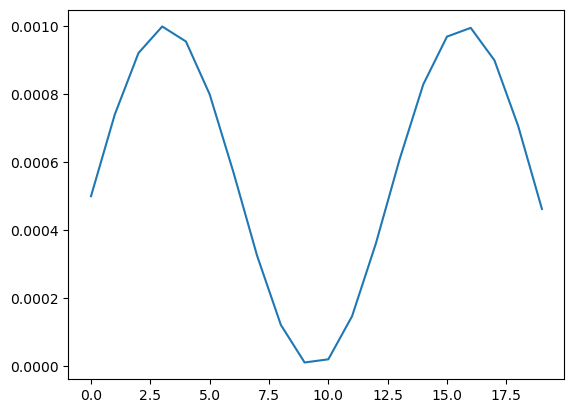

In [47]:
plt.plot(M1)

In [48]:
class TransportModel:
    def __init__(
        self, nt: int, geochem: GeochemicalParameters, tr_params: TransportParameters
    ) -> None:
        self.conc = np.zeros((nx, ny, nt + 1))
        self.conc[:, :, 0] = geochem.conc
        self.grade = np.zeros((nx, ny, nt + 1))
        self.grade[:, :, 0] = geochem.grade
        self.grade_prev = np.zeros((nx, ny))
        self.porosity = np.zeros((nx, ny))
        self.porosity[:, :] = tr_params.porosity
        self.diffusion = np.zeros((nx, ny))
        self.diffusion[:, :] = tr_params.diffusion
        self.fpi_eps = tr_params.fpi_eps


class AdjointTransportModel:
    def __init__(self, nt: int) -> None:
        self.a_conc = np.zeros((nx, ny, nt + 1))
        self.a_grade = np.zeros((nx, ny, nt + 1))
        self.a_conc_prev = np.zeros((nx, ny))

In [49]:
def solve_transport(
    tr_model: TransportModel,
    time_index: int,
    nfpi: int,
    is_numerical_acceleration: bool = False,
) -> None:
    """Solve the transport.

    Parameters
    ----------
    tr_model: TransportModel
        The transport model.
    time_index: int
        The iteration, or timestep id.
    nfpi:
        Number of fixed point iterations.
    is_numerical_acceleration: bool
        Whether to use the chemical source term of the previous iteration as a first
        guess. It can save one inner iteration per timestep iteration.
        The default is false.

    """
    # Chemical source term
    if is_numerical_acceleration and nfpi == 1 and time_index != 1:
        dmdt = (
            tr_model.grade[:, :, time_index - 1] - tr_model.grade[:, :, time_index - 2]
        )
    else:
        dmdt = tr_model.grade[:, :, time_index] - tr_model.grade[:, :, time_index - 1]

    # Transport of mobile species
    tr_model.conc[:, :, time_index] = (1 - tr_model.diffusion) * tr_model.conc[
        :, :, time_index - 1
    ] - dmdt


def solve_geochem(
    tr_model: TransportModel,
    gch_params: GeochemicalParameters,
    time_params: TimeParameters,
    time_index: int,
) -> None:
    """Compute the geochemistry part."""

    # Need to take into account boundary conditions:
    # And then the reactive (chemistry) contribution with the updated conc

    # Note: the concentration has been modified by the transport so we need to use the
    # updated one.
    # m0 = tr_model.grade_post_tr[:, :, time_index]
    m0 = tr_model.grade[:, :, time_index - 1]

    # The mobile concentration is from the transport
    dMdt = (
        gch_params.kv
        * gch_params.As
        * m0
        * (1.0 - tr_model.conc[:, :, time_index] / gch_params.Ks)
    )

    tr_model.grade[:, :, time_index] = m0 + dMdt * time_params.dt


def get_max_coupling_error(tr_model: TransportModel, time_index: int) -> float:
    """
    Return the maximum transport-chemistry coupling error.

    This error is evaluated from the immobile concentrations (mineral grades).
    """
    return float(
        np.nan_to_num(
            np.nanmax(
                np.abs(1 - tr_model.grade[:, :, time_index] / tr_model.grade_prev)
            ),
            nan=0.0,
        )
    )

In [50]:
tr_model_ref = TransportModel(time_params.nt, gch_params_ref, tr_params)
tr_model_ref.grade[:, :, 0] = M0
tr_model_est = TransportModel(time_params.nt, gch_params_est, tr_params)
tr_model_est.grade[:, :, 0] = M1


def solve_forward(
    _time_params: TimeParameters,
    _gch_params: GeochemicalParameters,
    _tr_model: TransportModel,
    is_verbose: bool = False,
) -> None:
    _time_params.reset_dt()
    # Otherwise there is an issue
    for it in range(1, _time_params.nt + 1):
        nfpi = 1  # number of coupling (Fixed Point) iterations
        # Do not update the timestep for the first iteration
        # update the timestep based on the convergence speed.
        if it != 1:
            _time_params.update_dt(nfpi)
        # Convergence flag
        has_converged = False

        # Copy the grades (To place in another function afterwards)
        _tr_model.grade[:, :, it] = _tr_model.grade[:, :, it - 1]

        # Iterate the chemistry transport system while the convergence is no meet
        while not has_converged:
            # Save the grade for the fix point iterations
            _tr_model.grade_prev = _tr_model.grade[:, :, it].copy()

            solve_transport(_tr_model, it, nfpi, is_numerical_acceleration=True)
            solve_geochem(_tr_model, _gch_params, time_params, it)

            # One more coupling iteration has been performed

            if is_verbose:
                print(
                    f"max-coupling error at it = {it}-{nfpi}: {get_max_coupling_error(_tr_model, it)}"
                )
            has_converged = get_max_coupling_error(_tr_model, it) < _tr_model.fpi_eps
            if is_verbose:
                print(f"has-converged ?: {has_converged}")

            # Update the number of FPI
            nfpi += 1


solve_forward(time_params, gch_params_ref, tr_model_ref, is_verbose=True)
solve_forward(time_params, gch_params_est, tr_model_est)

max-coupling error at it = 1-1: 3.254988391665492e-05
has-converged ?: False
max-coupling error at it = 1-2: 2.4027935197068473e-09
has-converged ?: False
max-coupling error at it = 1-3: 1.7741363933510002e-13
has-converged ?: True
max-coupling error at it = 2-1: 0.0033246454771853617
has-converged ?: False
max-coupling error at it = 2-2: 2.4381342957013885e-05
has-converged ?: False
max-coupling error at it = 2-3: 1.799640518829193e-07
has-converged ?: False
max-coupling error at it = 2-4: 1.328386955989913e-09
has-converged ?: False
max-coupling error at it = 2-5: 9.805489753489383e-12
has-converged ?: True
max-coupling error at it = 3-1: 0.003511210085603733
has-converged ?: False
max-coupling error at it = 3-2: 1.5485403264126063e-06
has-converged ?: False
max-coupling error at it = 3-3: 1.1962283830158071e-08
has-converged ?: False
max-coupling error at it = 3-4: 9.240741505323058e-11
has-converged ?: True
max-coupling error at it = 4-1: 0.003729181827376582
has-converged ?: False

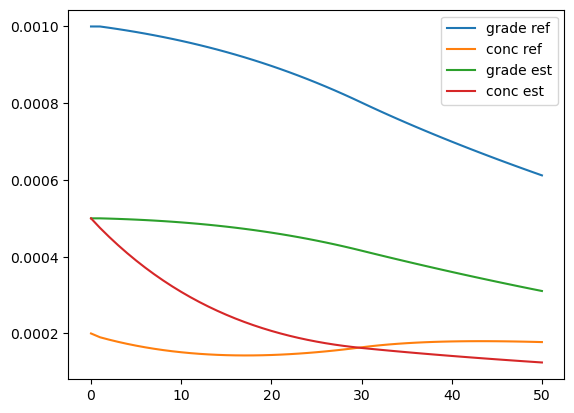

In [51]:
import matplotlib.pyplot as plt

plt.plot(tr_model_ref.grade[0, 0, :], label="grade ref")
plt.plot(tr_model_ref.conc[0, 0, :], label="conc ref")
plt.plot(tr_model_est.grade[0, 0, :], label="grade est")
plt.plot(tr_model_est.conc[0, 0, :], label="conc est")
plt.legend()

- Build an inverse

$$
\begin{cases}
    \lambda_{c_{i}}^{N+1} = - \dfrac{c_{i}^{N+1, \mathrm{obs}} - c_{i}^{N+1, \mathrm{calc}}}{ \left(\sigma_{c_{i}}^{N+1, \mathrm{obs}}\right)^{2}} \dfrac{1}{1 - \Delta t^{N} k_{v} A_{s} \dfrac{\overline{c}_{i}^{N}}{Ks}}, & \text{Initial condition}
    \\\\
    \lambda_{\overline{c}_{i}}^{N+1} = -\lambda_{c_{i}}^{N+1}, & \text{Initial condition}
    \\\\
    \lambda_{\overline{c}_{i}}^{n} = \lambda_{\overline{c}_{i}}^{n+1} \left(1 +  \Delta t^{n} k_{v} A_{s} \left( 1 - \dfrac{c_{i}^{n+1}}{K_{s}}\right) \right) - \left(\lambda_{c_{i}}^{n} - \lambda_{c_{i}}^{n+1}\right), & \forall n \in [1, N]
    \\\\
    \lambda_{c_{i}}^{n} = \lambda_{c_{i}}^{n+1} (1 - D_{i}) - \lambda_{\overline{c}_{i}}^{n} \Delta t^{n-1} k_{v} A_{s} \dfrac{\overline{c}_{i}^{n-1}}{Ks} - \dfrac{c_{i}^{n, \mathrm{obs}} - c_{i}^{n, \mathrm{calc}}}{\left(\sigma_{c_{i}}^{n, \mathrm{obs}}\right)^{2}}, & \forall n \in [1, N] 
\end{cases}
$$

In [52]:
def solve_adjoint_geochem(
    tr_model: TransportModel,
    atr_model: AdjointTransportModel,
    gch_params: GeochemicalParameters,
    time_params: TimeParameters,
    time_index: int,
    nafpi: int,
    is_numerical_acceleration: bool = False,
) -> None:
    # Adjoint variables
    am_old = atr_model.a_grade[:, :, time_index + 1]
    ac_old = atr_model.a_conc[:, :, time_index + 1]
    ac_cur = atr_model.a_conc[:, :, time_index]
    # Forward variables
    c_old = tr_model.conc[:, :, time_index + 1]
    # Timesteps
    dt_cur = time_params.ldt[time_index]

    # Update mineral value
    atr_model.a_grade[:, :, time_index] = am_old * (
        1 + gch_params.kv * gch_params.As * (1.0 - c_old / gch_params.Ks) * dt_cur
    ) - (
        ac_cur - ac_old
    )  # transport adjoint source term


def solve_adjoint_transport(
    tr_model: TransportModel,
    atr_model: AdjointTransportModel,
    gch_params: GeochemicalParameters,
    a_sources: NDArrayFloat,
    time_index: int,
) -> None:
    # This works
    ac_old = atr_model.a_conc[:, :, time_index + 1]

    # Update mineral value
    atr_model.a_conc[:, :, time_index] = (
        ac_old * (1 - tr_model.diffusion)
        - atr_model.a_grade[:, :, time_index]
        * time_params.ldt[time_index - 1]
        * gch_params.kv
        * gch_params.As
        * (tr_model.grade[:, :, time_index - 1] / gch_params.Ks)
        - a_sources[:, :, time_index]
    )


def get_adjoint_max_coupling_error(
    atr_model: AdjointTransportModel, time_index: int
) -> float:
    """
    Return the maximum transport-chemistry coupling error.

    This error is evaluated from the immobile concentrations (mineral grades).
    """
    return float(
        np.nan_to_num(
            np.max(
                np.abs(1 - atr_model.a_conc[:, :, time_index] / atr_model.a_conc_prev)
            ),
            nan=0.0,
        )
    )

In [53]:
def get_a_sources(
    tr_model_ref: TransportModel, tr_model_est: TransportModel
) -> NDArrayFloat:
    _out = tr_model_ref.conc - tr_model_est.conc
    # Modify here to remove some of the adjoint variables
    # _out[:, :, 2:] = 0.0
    return _out


def _init_adjoint_variables(
    tr_model: TransportModel,
    atr_model: AdjointTransportModel,
    _gch_params: GeochemicalParameters,
    _a_sources: NDArrayFloat,
    _time_params: TimeParameters,
    method: str,
    is_verbose: bool = False,
) -> None:
    if method == "direct":
        atr_model.a_conc[:, :, -1] -= _a_sources[:, :, -1] / (
            1
            - _time_params.ldt[-1]
            * _gch_params.kv
            * _gch_params.As
            * tr_model_est.grade[:, :, -2]
            / _gch_params.Ks
        )
        atr_model.a_grade[:, :, -1] = -atr_model.a_conc[
            :, :, -1
        ]  # no observable for mineral
    else:
        print(" - Adjoint variables initialization !")
        # fixed point iterations
        has_converged = False
        nafpi = 1

        atr_model.a_conc[:, :, -1] = -_a_sources[:, :, -1] - atr_model.a_grade[
            :, :, -1
        ] * (
            _time_params.ldt[-1]
            * _gch_params.kv
            * _gch_params.As
            * tr_model_est.grade[:, :, -2]
            / _gch_params.Ks
        )
        atr_model.a_grade[:, :, -1] = -atr_model.a_conc[
            :, :, -1
        ]  # no observable for mineral

        while not has_converged:
            nafpi += 1

            atr_model.a_conc_prev = atr_model.a_conc[:, :, -1].copy()

            atr_model.a_conc[:, :, -1] = -_a_sources[:, :, -1] - atr_model.a_grade[
                :, :, -1
            ] * (
                _time_params.ldt[-1]
                * _gch_params.kv
                * _gch_params.As
                * tr_model_est.grade[:, :, -2]
                / _gch_params.Ks
            )
            atr_model.a_grade[:, :, -1] = -atr_model.a_conc[
                :, :, -1
            ]  # no observable for mineral

            has_converged = (
                get_adjoint_max_coupling_error(atr_model, -1) < tr_model.fpi_eps
            )

            if is_verbose:
                print(
                    f"max-coupling error at it = {time_params.nt + 1}-{nafpi}: {get_adjoint_max_coupling_error(atr_model, -1)}"
                )
            has_converged = (
                get_adjoint_max_coupling_error(atr_model, -1) < tr_model.fpi_eps
            )
            if is_verbose:
                print(f"has-converged ?: {has_converged}")
        print(" - Adjoint variables initializatied !")


def solve_adjoint_system(
    _time_params: TimeParameters,
    _gch_params: GeochemicalParameters,
    _tr_model: TransportModel,
    is_verbose: bool = False,
) -> AdjointTransportModel:
    # Build an adjoint model
    atr_model = AdjointTransportModel(time_params.nt)

    # Add the adjoint sources
    _a_sources = get_a_sources(tr_model_ref, tr_model_est)

    # Initiate adjoint concentrations and grades
    _init_adjoint_variables(
        _tr_model, atr_model, _gch_params, _a_sources, _time_params, "fpi", True
    )

    # Otherwise there is an issue
    for it in range(time_params.nt - 1, 0, -1):
        nafpi = 1  # number of coupling (Fixed Point) iterations
        # Convergence flag for the adjoint
        has_converged = False

        # Copy the grades (To place in another function afterwards)
        atr_model.a_conc[:, :, it] = atr_model.a_conc[:, :, it + 1]

        # print(atr_model.a_conc[:, :, it])

        # Iterate the chemistry transport system while the convergence is no meet
        while not has_converged:
            # Save the grade for the fix point iterations
            atr_model.a_conc_prev = atr_model.a_conc[:, :, it].copy()

            solve_adjoint_geochem(
                _tr_model,
                atr_model,
                _gch_params,
                time_params,
                it,
                nafpi,
                is_numerical_acceleration=True,
            )

            solve_adjoint_transport(_tr_model, atr_model, _gch_params, _a_sources, it)

            # One more coupling iteration has been performed

            if is_verbose:
                print(
                    f"max-coupling error at it = {it}-{nafpi}: {get_adjoint_max_coupling_error(atr_model, it)}"
                )
            has_converged = (
                get_adjoint_max_coupling_error(atr_model, it) < _tr_model.fpi_eps
            )
            if is_verbose:
                print(f"has-converged ?: {has_converged}")

            # Update the number of FPI
            nafpi += 1
    return atr_model


atr_model = solve_adjoint_system(
    time_params, gch_params_est, tr_model_est, is_verbose=True
)

 - Adjoint variables initialization !
max-coupling error at it = 51-2: 0.019499120891145583
has-converged ?: False
max-coupling error at it = 51-3: 0.00038777702664893887
has-converged ?: False
max-coupling error at it = 51-4: 7.558380155092692e-06
has-converged ?: False
max-coupling error at it = 51-5: 1.4738288234283914e-07
has-converged ?: False
max-coupling error at it = 51-6: 2.8738362800595496e-09
has-converged ?: False
max-coupling error at it = 51-7: 5.6037174900325226e-11
has-converged ?: True
 - Adjoint variables initializatied !
max-coupling error at it = 49-1: 1.1417246710238937
has-converged ?: False
max-coupling error at it = 49-2: 0.009824728778372482
has-converged ?: False
max-coupling error at it = 49-3: 0.00019599621028887348
has-converged ?: False
max-coupling error at it = 49-4: 3.870809001771391e-06
has-converged ?: False
max-coupling error at it = 49-5: 7.646146293893707e-08
has-converged ?: False
max-coupling error at it = 49-6: 1.5103642780900373e-09
has-converg

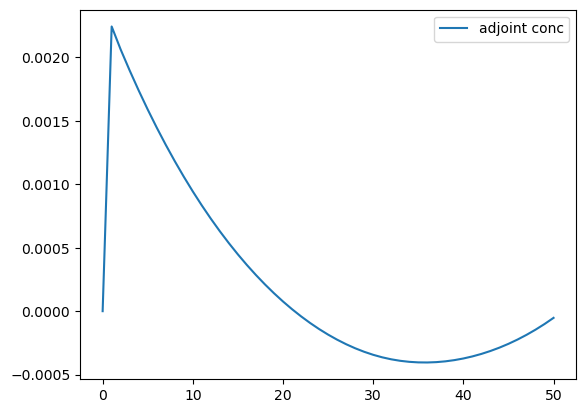

In [54]:
plt.plot(atr_model.a_conc[0, 0, :], label="adjoint conc")
plt.legend()

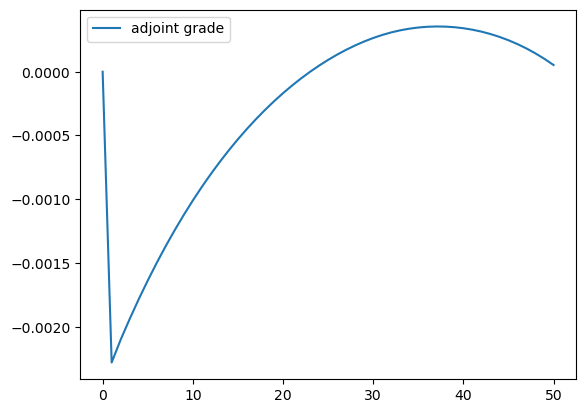

In [55]:
plt.plot(atr_model.a_grade[0, 0, :], label="adjoint grade")
plt.legend()

# Gradient computation

$$\dfrac{\partial \mathcal{L}}{\partial \overline{c}_{i}^{0}} = \lambda_{c_{i}}^{1} + \lambda_{\overline{c}_{i}}^{1} \left( 1 + \Delta t^{0} k_{v} A_{s} \left( 1 - \dfrac{c_{i}^{1}}{K_{s}}\right) \right)$$

In [56]:
gch_params = gch_params_est


def get_init_mineral_gradient(time_params: TimeParameters):
    return atr_model.a_conc[:, :, 1] + atr_model.a_grade[:, :, 1] * (
        1
        + time_params.ldt[0]
        * gch_params.kv
        * gch_params.As
        * (1.0 - tr_model_est.conc[:, :, 1] / gch_params.Ks)
    )


adjoint_init_min_gradient = get_init_mineral_gradient(time_params=time_params).ravel()
adjoint_init_min_gradient

array([-3.61545385e-05,  6.80452139e-05,  1.30700924e-04,  1.54036074e-04,
        1.41099332e-04,  9.00389257e-05, -2.70685648e-06, -1.30589429e-04,
       -2.62708639e-04, -3.46258726e-04, -3.38870768e-04, -2.44542771e-04,
       -1.09992435e-04,  1.38714681e-05,  1.00336032e-04,  1.45380911e-04,
        1.52869655e-04,  1.23902588e-04,  5.49678647e-05, -5.49889766e-05])

$$\dfrac{\partial \mathcal{L}}{\partial c_{i}^{0}} = - \dfrac{c_{i}^{0, \mathrm{obs}} - c_{i}^{0, \mathrm{calc}}}{\left(\sigma_{c_{i}}^{0, \mathrm{obs}}\right)^{2}} + \lambda_{c_{i}}^{1} (1 - D_{i})$$

In [57]:
gch_params = gch_params_est


def get_init_conc_gradient(time_params: TimeParameters):
    _a_sources = get_a_sources(tr_model_ref, tr_model_est)

    return -_a_sources[:, :, 0] + atr_model.a_conc[:, :, 1] * (
        1 - tr_model_est.diffusion
    )


adjoint_init_conc_gradient = get_init_conc_gradient(time_params=time_params).ravel()
adjoint_init_conc_gradient

array([0.00243146, 0.00255263, 0.00262655, 0.00265431, 0.00263891,
       0.00257848, 0.00247013, 0.0023233 , 0.00217417, 0.00208101,
       0.00208921, 0.00219454, 0.00234677, 0.00248938, 0.00259062,
       0.002644  , 0.00265292, 0.00261849, 0.0025373 , 0.00240978])

- Objective function definition

In [58]:
def objfun_init_min(x, time_params: TimeParameters) -> float:
    _tr_model = TransportModel(time_params.nt, gch_params_est, tr_params)
    _tr_model.grade[:, :, 0] = x.reshape(nx, ny, order="F")
    solve_forward(time_params, gch_params_est, _tr_model, is_verbose=False)

    _a_sources = get_a_sources(tr_model_ref, _tr_model)
    return float(0.5 * np.sum(_a_sources**2))


def objfun_init_conc(x, time_params: TimeParameters) -> float:
    _tr_model = TransportModel(time_params.nt, gch_params_est, tr_params)
    _tr_model.conc[:, :, 0] = x.reshape(nx, ny, order="F")
    solve_forward(time_params, gch_params_est, _tr_model, is_verbose=False)

    _a_sources = get_a_sources(tr_model_ref, _tr_model)
    return float(0.5 * np.sum(_a_sources**2))

- Evaluate the objective function for the initial guess

In [59]:
objfun_init_min(M1, time_params)

7.785144000525457e-06

In [60]:
objfun_init_conc(M1, time_params)

2.4719996824600628e-05

- Define a step for the finite differences

In [61]:
import sys

eps = sys.float_info.epsilon * 1e6
eps

2.220446049250313e-10

- We check the gradients by finite differences (with pyrtid and numdifftools, it is supposed to give the same results, the main difference is that pyrtid supports parallel running.)

In [62]:
def objfun_wrapper_init_min(x: NDArrayFloat) -> float:
    return objfun_init_min(x, time_params)


def objfun_wrapper_init_conc(x: NDArrayFloat) -> float:
    return objfun_init_conc(x, time_params)


fd_init_min_gradient_numdifftools = nd.Gradient(objfun_wrapper_init_min, step=eps)(
    tr_model_est.grade[:, :, 0].ravel("F")
)
fd_init_min_gradient_pyrtid = finite_gradient(
    tr_model_est.grade[:, :, 0].ravel("F"),
    objfun_init_min,
    fm_args=(time_params,),
    eps=eps,
)

fd_init_conc_gradient_numdifftools = nd.Gradient(objfun_wrapper_init_conc, step=eps)(
    tr_model_est.conc[:, :, 0].ravel("F")
)
fd_init_conc_gradient_pyrtid = finite_gradient(
    tr_model_est.conc[:, :, 0].ravel("F"),
    objfun_init_conc,
    fm_args=(time_params,),
    eps=eps,
)

- Plot the gradients

In [63]:
adjoint_init_min_gradient / fd_init_min_gradient_pyrtid

array([1.00000003, 0.99999992, 1.        , 0.99999999, 0.99999998,
       1.00000001, 0.99999885, 0.99999998, 1.00000002, 1.        ,
       1.00000001, 1.        , 1.        , 1.00000004, 0.99999999,
       1.00000001, 0.99999999, 1.        , 0.99999999, 1.00000002])

In [64]:
adjoint_init_conc_gradient / fd_init_conc_gradient_pyrtid

array([1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
       1., 1., 1.])

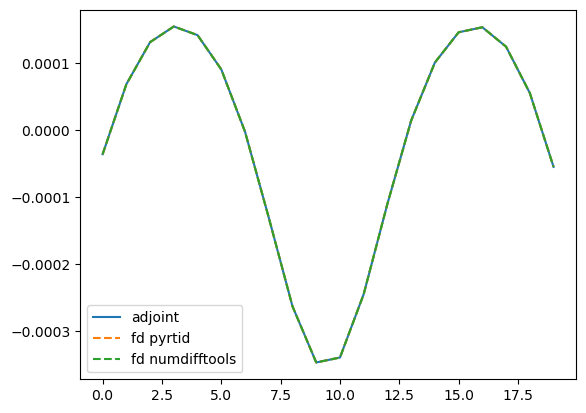

In [65]:
plt.plot(adjoint_init_min_gradient, label="adjoint")
plt.plot(fd_init_min_gradient_pyrtid, label="fd pyrtid", linestyle="--")
plt.plot(fd_init_min_gradient_numdifftools, label="fd numdifftools", linestyle="--")
plt.legend()

- Plot the residuals

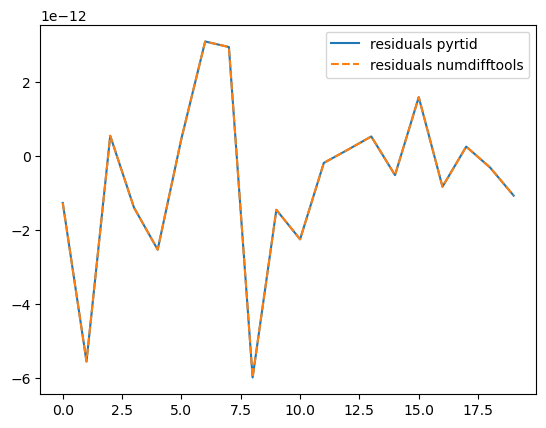

In [66]:
plt.plot(
    (adjoint_init_min_gradient - fd_init_min_gradient_pyrtid), label="residuals pyrtid"
)
plt.plot(
    (adjoint_init_min_gradient - fd_init_min_gradient_numdifftools),
    linestyle="--",
    label="residuals numdifftools",
)
plt.legend()

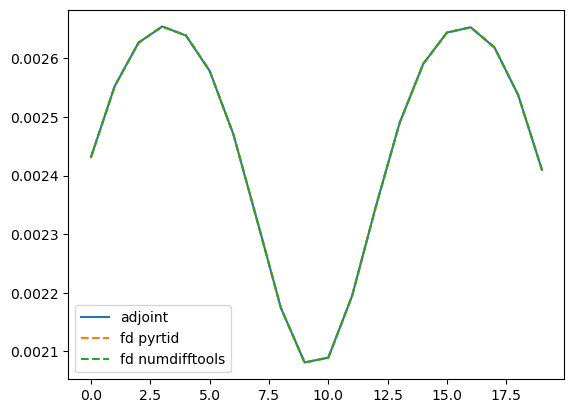

In [67]:
plt.plot(adjoint_init_conc_gradient, label="adjoint")
plt.plot(fd_init_conc_gradient_pyrtid, label="fd pyrtid", linestyle="--")
plt.plot(fd_init_conc_gradient_numdifftools, label="fd numdifftools", linestyle="--")
plt.legend()

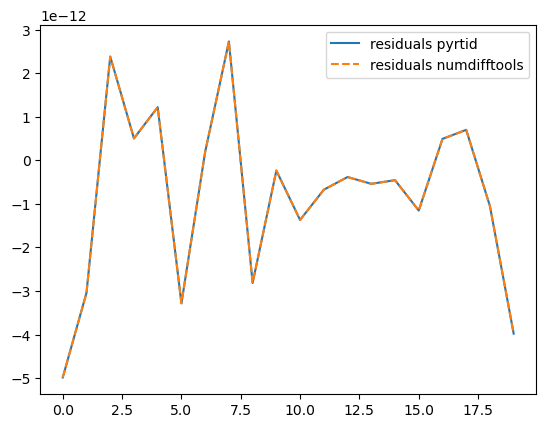

In [68]:
plt.plot(
    (adjoint_init_conc_gradient - fd_init_conc_gradient_pyrtid),
    label="residuals pyrtid",
)
plt.plot(
    (adjoint_init_conc_gradient - fd_init_conc_gradient_numdifftools),
    linestyle="--",
    label="residuals numdifftools",
)
plt.legend()